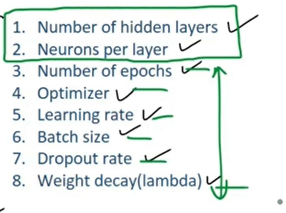



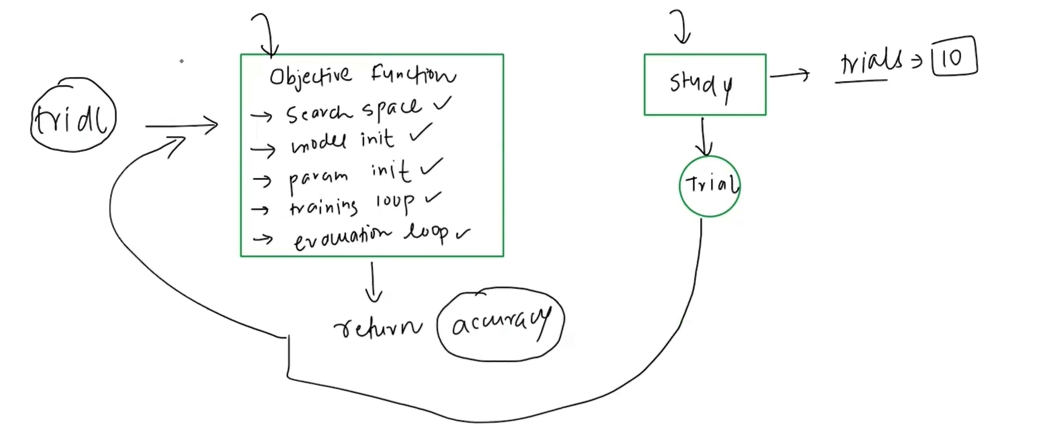

In [38]:
import pandas as pd
from sklearn.model_selection import train_test_split
import torch
from torch.utils.data import Dataset, DataLoader
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt



In [39]:
# Set random seeds for reproducibility
torch.manual_seed(42)

In [40]:
# Check.for GPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


In [41]:
df = pd. read_csv('fashion-mnist_train.csv')
df. head()

,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,2,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,9,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,6,0,0,0,0,0,0,0,5,0,...,0,0,0,30,43,0,0,0,0,0
3,0,0,0,0,1,2,0,0,0,0,...,3,0,0,0,0,1,0,0,0,0
4,3,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [42]:
df.shape

(60000, 785)

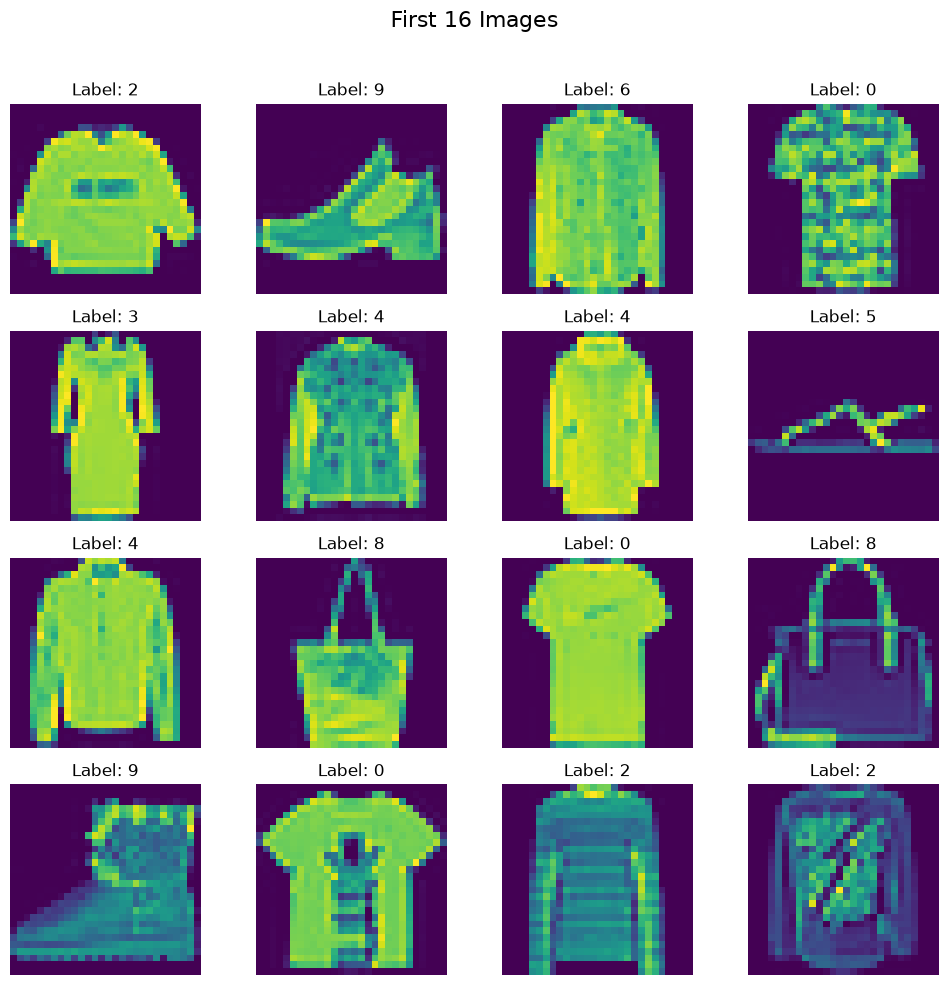

In [43]:
# Create a 4x4 grid of images
fig, axes = plt.subplots(4, 4, figsize=(10, 10))
fig.suptitle("First 16 Images", fontsize=16)

# Plot the first 16 images from the dataset
for i, ax in enumerate(axes.flat):
    img = df.iloc[i, 1:].values.reshape(28, 28)  # Reshape to 28x28
    ax.imshow(img)  # Display in grayscale
    ax.axis('off')  # Remove axis for a cleaner look
    ax.set_title(f"Label: {df.iloc[i, 0]}")  # Show the label

plt.tight_layout(rect=[0, 0, 1, 0.96])  # Adjust layout to fit the title
plt.show()


In [44]:
# train test split

X = df.iloc[:, 1:].values
y = df.iloc[:, 0].values

In [45]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [46]:
X_train = X_train/255.0
X_test = X_test/255.0

In [47]:
class CustomDataset(Dataset):

  def __init__(self, features, labels):

    # Convert to PyTorch tensors
    self.features = torch.tensor(features, dtype=torch.float32)
    self.labels = torch.tensor(labels, dtype=torch.long)

  def __len__(self):
    return len(self.features)

  def __getitem__(self, index):
    return self.features[index], self.labels[index]

In [48]:
train_dataset = CustomDataset(X_train, y_train)

In [49]:
test_dataset = CustomDataset(X_test, y_test)

In [50]:
len(train_loader)

1500

In [51]:
class MyNN(nn.Module):

    def __init__(self, input_dim, output_dim, num_hidden_layers, neurons_per_layer,dropout_rate):
        
        super() .__init__()
        
        layers = []
    
        for i in range(num_hidden_layers):
        
            layers.append(nn.Linear(input_dim, neurons_per_layer))
            layers.append(nn.BatchNorm1d(neurons_per_layer))
            layers.append(nn.ReLU())
            layers.append(nn.Dropout(dropout_rate))
            input_dim = neurons_per_layer
            
        layers. append(nn. Linear(neurons_per_layer, output_dim))

        self.model = nn.Sequential(*layers)
    def forward (self,x):
        return self.model(x)

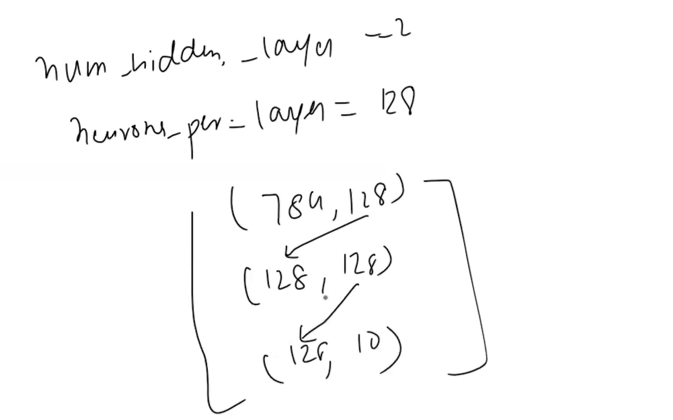

In [74]:
#objective function
def objective(trial):
     # next hyperparameter values from the search space
    num_hidden_layers = trial.suggest_int("num_hidden_layers", 1, 5)
    neurons_per_layer = trial.suggest_int("neurons_per_layer", 8, 128, step=8)
    epochs = trial.suggest_int("epochs",10,50,step=10)
    learning_rate = trial.suggest_float("learning_rate",1e-5,1e-1,log=True)
    dropout_rate = trial.suggest_float("dropout_rate", 0.1, 0.5, step=0.1)
    batch_size = trial.suggest_categorical("batch_size", [16, 32, 64, 128])
    optimizer_name = trial.suggest_categorical("optimizer", ['Adam', 'SGD', 'RMSprop'])
    weight_decay = trial. suggest_float("weight_decay", 1e-5, 1e-3, log=True)

    
    train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, pin_memory=True)
    test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, pin_memory=True)


    # model init
    input_dim = 784
    output_dim = 10
    
    model = MyNN(input_dim, output_dim, num_hidden_layers, neurons_per_layer,dropout_rate)
    model.to(device)
    # params init

    # optimizer selection
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.SGD(model.parameters(), lr=0.1, weight_decay=1e-4 )
    
    if optimizer_name == 'Adam':
        optim.Adam(model.parameters(), lr=learning_rate, weight_decay=weight_decay )
    elif optimizer_name =='SGD': 
        optim.SGD(model.parameters(), lr=learning_rate, weight_decay=weight_decay )
    else :
        optim.RMSprop(model.parameters(), lr=learning_rate, weight_decay=weight_decay)
    
    # training loop

    for epoch in range(epochs):
    
        for batch_features, batch_labels in train_loader:
        
            # move data to gpu
            batch_features, batch_labels = batch_features.to(device), batch_labels.to(device)
            
            # forward pass
            outputs = model(batch_features)
            
            # calculate loss
            loss = criterion(outputs, batch_labels)
                        
            # back pass
            optimizer.zero_grad()
            loss.backward()
            
            # update grads
            optimizer.step()
            
        # evaluation
        model.eval()
        # evaluation on test data
        total = 0
        correct = 0
        
        with torch.no_grad():
        
            for batch_features, batch_labels in test_loader:
               # move data to gpu
                batch_features, batch_labels = batch_features.to(device), batch_labels.to(device)
                
                outputs = model(batch_features)
                
                _, predicted = torch.max(outputs, 1)
                
                total = total + batch_labels. shape[0]
                
                correct = correct + (predicted == batch_labels).sum().item()
                
            accuracy = correct/total
                
        return accuracy         

In [75]:
import optuna
study = optuna.create_study(direction='maximize')

[I 2026-07-01 14:31:12,410] A new study created in memory with name: no-name-e16dee67-71c0-430c-9df8-8695de50d8bf


In [76]:
study.optimize(objective,n_trials=10)

[I 2026-07-01 14:31:18,302] Trial 0 finished with value: 0.82475 and parameters: {'num_hidden_layers': 1, 'neurons_per_layer': 40, 'epochs': 20, 'learning_rate': 0.0005628020332753282, 'dropout_rate': 0.5, 'batch_size': 32, 'optimizer': 'Adam', 'weight_decay': 0.00016524949663721892}. Best is trial 0 with value: 0.82475.
[I 2026-07-01 14:31:23,423] Trial 1 finished with value: 0.829 and parameters: {'num_hidden_layers': 1, 'neurons_per_layer': 24, 'epochs': 50, 'learning_rate': 0.0002509418570308043, 'dropout_rate': 0.30000000000000004, 'batch_size': 128, 'optimizer': 'SGD', 'weight_decay': 0.00016957876429893705}. Best is trial 1 with value: 0.829.
[I 2026-07-01 14:31:34,344] Trial 2 finished with value: 0.8486666666666667 and parameters: {'num_hidden_layers': 5, 'neurons_per_layer': 104, 'epochs': 50, 'learning_rate': 0.0034224362234859494, 'dropout_rate': 0.1, 'batch_size': 64, 'optimizer': 'RMSprop', 'weight_decay': 1.713020015367398e-05}. Best is trial 2 with value: 0.848666666666

In [78]:
study.best_value

0.849

In [79]:
study.best_params

{'num_hidden_layers': 2,
 'neurons_per_layer': 112,
 'epochs': 10,
 'learning_rate': 0.012302109243097624,
 'dropout_rate': 0.2,
 'batch_size': 128,
 'optimizer': 'RMSprop',
 'weight_decay': 0.00010990784071782656}